## Tensorflow를 활용한 딥러닝 1

In [88]:
pip install tensorflow

### 1. 간단한 신경망 모델 구성 및 훈련

##### 필요한 라이브러리 로드

In [89]:
# TensorFlow와 Keras의 기능을 사용하기 위해 필요한 모듈을 불러옴
import numpy as np
from tensorflow.keras.models import Sequential          # 순차적 모델을 생성하기 위한 모듈
from tensorflow.keras.layers import Dense               # 밀집층(fully connected layer)을 추가하기 위한 모듈
from sklearn.model_selection import train_test_split    # 데이터를 학습/테스트 세트로 나누기 위한 모듈
from sklearn.datasets import make_classification        # 예제 데이터셋 생성 모듈


##### 데이터 생성 및 전처리

In [90]:
# 예제용으로 가상 데이터셋을 생성
X, y = make_classification(
    n_samples=1000,     # 데이터 샘플 수
    n_features=20,      # 특징(특성) 수
    n_classes=2,        # 클래스 수 (이진 분류)
    random_state=42     # 랜덤 시드 고정 (결과 재현 가능성 보장)
)

# 데이터를 학습용(train)과 테스트용(test)으로 나눔
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### 모델 생성

In [91]:
# Sequential()은 모델을 레이어 순서대로 구성할 수 있도록 해줌
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),  # 첫 번째 은닉층
    Dense(8, activation='relu'),                                    # 두 번째 은닉층
    Dense(1, activation='sigmoid')                                  # 출력층 (이진 분류에서 사용)
])

# 여기서 `input_shape`는 입력 데이터의 차원을 지정합니다.
# `activation`은 각 층에서 사용할 활성화 함수입니다.
# -relu: 0보다 큰 값은 그대로 두고, 작은 값은 0으로 설정 (비선형성 제공)
# -sigmoid: 출력값을 0과 1 사이로 제한 (이진 분류에서 확률 계산에 유용)


c:\Users\ez\Desktop\sk-shielders-rookies-26\project\python\tensorflow\.venv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### 모델 컴파일

In [ ]:
# 모델 학습 전에 학습 방법(optimizer), 손실 함수(loss), 평가 지표(metrics)를 정의
model.compile(
  optimizer='adam',             # 학습 속도를 조정하며 손실 함수의 최솟값을 찾습니다.
  loss='binary_crossentropy',   # 이진 분류에서 자주 사용되는 손실 함수
  metrics=['accuracy']          # 학습 성과를 평가할 지표
)

##### 모델 훈련

In [93]:
# fit() 메서드는 모델을 학습시키는 역할을 함
history = model.fit(
    X_train, y_train,       # 학습용 데이터와 레이블
    validation_split=0.2,   # 검증 데이터 비율 (학습 데이터의 20%)
    epochs=10,              # 학습 반복 횟수
    batch_size=32,          # 한 번의 학습에서 사용하는 데이터 샘플 수
    verbose=1               # 학습 진행 상태를 출력
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5542 - loss: 0.7526 - val_accuracy: 0.6062 - val_loss: 0.6205
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6242 - loss: 0.6413 - val_accuracy: 0.6812 - val_loss: 0.5679
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6848 - loss: 0.6144 - val_accuracy: 0.8062 - val_loss: 0.5298
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7662 - loss: 0.5454 - val_accuracy: 0.8500 - val_loss: 0.4981
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7927 - loss: 0.5187 - val_accuracy: 0.8375 - val_loss: 0.4653
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7880 - loss: 0.4969 - val_accuracy: 0.8625 - val_loss: 0.4347
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8510 - loss: 0.4411 - val_accuracy: 0.8750 - val_loss: 0.4032
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8550 - loss: 0.4208 - val_accuracy: 0.8938 - val_loss:

##### 모델 평가 및 예측

In [94]:
# 모델 평가
# 테스트 데이터로 학습된 모델을 평가
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\n테스트 손실: {test_loss:.4f}, 테스트 정확도: {test_accuracy:.4f}\n")

# 모델 예측
# 학습된 모델을 사용해 새로운 데이터 예측
predictions = model.predict(X_test[:5]) # 테스트 데이터 중 5개의 샘플 예측
print("\n예측 결과:\n", predictions)

# 여기서 predictions의 출력은 확률 값
# 일반적으로 0.5 이상은 클래스 1, 미만은 클래스 0으로 간주


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8454 - loss: 0.4166  

테스트 손실: 0.4043, 테스트 정확도: 0.8500

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

예측 결과:
 [[0.801767  ]
 [0.40940955]
 [0.2148028 ]
 [0.81748796]
 [0.9205086 ]]


### 2. 이진 분류

In [126]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

##### 데이터 준비

In [157]:
# 예제 데이터 생성 (여기서는 임의로 데이터를 생성합니다. 실제 데이터로 교체 가능)
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000, n_features=20, n_informative=15, 
    n_redundant=5, random_state=42
)

# 데이터 분할: 훈련, 검증, 테스트 데이터셋
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# 데이터 정규화 (특성 스케일링)
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

##### 모델 설계

In [158]:
# 입력층, 은닉층, 출력층으로 구성된 이진 분류 모델
model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=(X_train.shape[1],)),   # 입력층
  tf.keras.layers.Dense(64, activation='relu'),       # 첫 번째 은닉층
  tf.keras.layers.Dropout(0.5),                       # 과적합 방지를 위한 Dropout
  tf.keras.layers.Dense(32, activation='relu'),       # 두 번째 은닉층
  tf.keras.layers.Dense(1, activation='sigmoid')      # 출력층 (Sigmoid 활성화 함수)
])

##### 모델 컴파일

In [159]:
# 손실 함수: Binary Cross-Entropy
# 최적화 알고리즘: Adam
# 평가지표: Accuracy
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

##### Early Stopping 설정

In [160]:
# 검증 데이터 손실이 개선되지 않으면 학습을 조기에 종료
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
 
# 모델 훈련
history = model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val), 
    epochs=50, 
    batch_size=32, 
    callbacks=[early_stopping]
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5349 - loss: 0.7063 - val_accuracy: 0.7733 - val_loss: 0.5765
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6940 - loss: 0.5818 - val_accuracy: 0.8000 - val_loss: 0.4916
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7506 - loss: 0.5399 - val_accuracy: 0.8467 - val_loss: 0.4269
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7999 - loss: 0.4568 - val_accuracy: 0.8600 - val_loss: 0.3727
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8094 - loss: 0.4096 - val_accuracy: 0.8867 - val_loss: 0.3322
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8290 - loss: 0.3935 - val_accuracy: 0.8933 - val_loss: 0.3013
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8451 - loss: 0.3542 - val_accuracy: 0.9000 - val_loss: 0.2752
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8455 - loss: 0.3603 - val_accuracy: 0.9133 - val_loss

##### 모델 훈련

In [161]:
history = model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val), 
    epochs=50, 
    batch_size=32, 
    callbacks=[early_stopping]
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9347 - loss: 0.1807 - val_accuracy: 0.9533 - val_loss: 0.0999
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9566 - loss: 0.1260 - val_accuracy: 0.9533 - val_loss: 0.1072
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9411 - loss: 0.1666 - val_accuracy: 0.9533 - val_loss: 0.1138
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9411 - loss: 0.1408 - val_accuracy: 0.9533 - val_loss: 0.1067
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9513 - loss: 0.1340 - val_accuracy: 0.9600 - val_loss: 0.1073
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9355 - loss: 0.1501 - val_accuracy: 0.9533 - val_loss: 0.1106
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9486 - loss: 0.1420 - val_accuracy: 0.9533 - val_loss: 0.1094
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9625 - loss: 0.1162 - val_accuracy: 0.9533 - val_loss:

##### 모델 평가

In [162]:
# 테스트 데이터로 성능 평가
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"TestLoss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9331 - loss: 0.1626 
TestLoss: 0.1458, Test Accuracy: 0.9400


##### 예측

In [163]:
# 새로운 데이터에 대한 예측 수행
predictions = model.predict(X_test)
predicted_classes=(predictions > 0.5).astype(int) # 0.5를 기준으로 클래스 결정

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [164]:
# 실제 값과 예측 값을 비교하여 성능 지표 확인
print("\nClassificationReport:")
print(classification_report(y_test, predicted_classes))


ClassificationReport:
              precision    recall  f1-score   support

           0       0.94      0.95      0.94        79
           1       0.94      0.93      0.94        71

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.94      0.94      0.94       150



##### 학습 결과 시각화 (Optional)

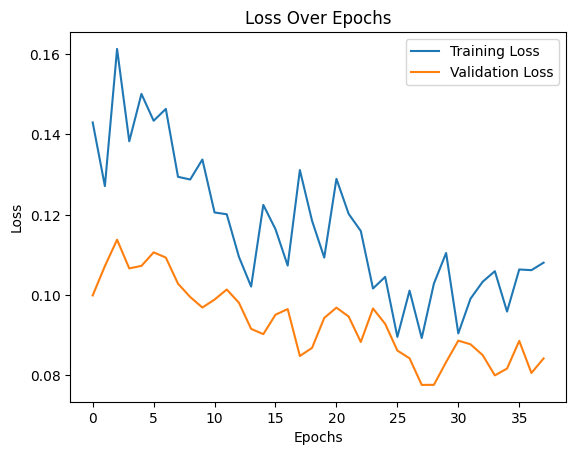

In [165]:
import matplotlib.pyplot as plt

# 훈련 및 검증 손실 시각화
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

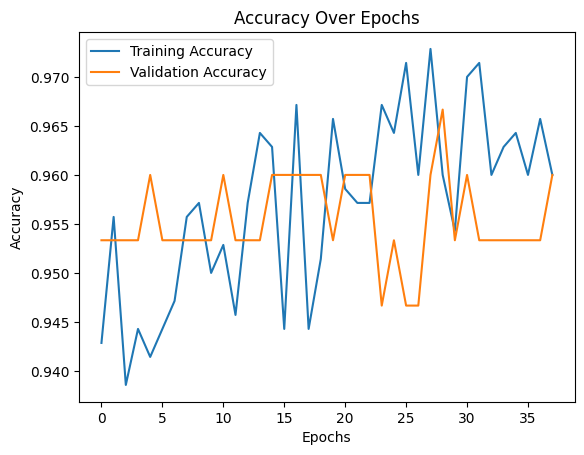

In [166]:
# 훈련 및 검증 정확도 시각화
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 3. MNIST 데이터셋을 활용한 이미지 분류

In [167]:
from tensorflow.keras.models import Sequential      # 순차적 모델 생성
from tensorflow.keras.layers import Dense           # 완전 연결(Dense) 층
from tensorflow.keras.utils import to_categorical   # 원-핫 인코딩
from tensorflow.keras.datasets import mnist         # MNIST 데이터셋 가져오기

##### 데이터 로드 및 전처리

In [168]:
# MNIST 데이터셋을 훈련 세트와 테스트 세트로 분리
(x_train, y_train), (x_test, y_test) =mnist.load_data()

# 입력 데이터(이미지)를 1차원 벡터로 변환하고 정규화 (0~1 범위로 스케일링)
x_train=x_train.reshape(-1, 784) /255.0 # 28x28 이미지를 784 길이의 벡터로 변환
x_test=x_test.reshape(-1, 784) /255.0

# 레이블(출력 값)을 원-핫 인코딩 (예: 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0])
y_train=to_categorical(y_train, num_classes=10)
y_test=to_categorical(y_test, num_classes=10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


##### 모델 구성

In [169]:
model=Sequential([
    # 첫 번째 은닉층: 뉴런 128개, 활성화 함수 ReLU, 입력 크기는 784
    Dense(128, activation='relu', input_shape=(784,)),
    # 두 번째 은닉층: 뉴런 64개, 활성화 함수 ReLU
    Dense(64, activation='relu'),
    # 출력층: 뉴런 10개 (클래스 수), 활성화 함수 Softmax
    Dense(10, activation='softmax')
])

c:\Users\ez\Desktop\sk-shielders-rookies-26\project\python\tensorflow\.venv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##### 모델 컴파일

In [170]:
# 손실 함수: Categorical Crossentropy
# 옵티마이저: Adam (효율적인 경사 하강법 알고리즘)
# 평가 지표: 정확도 (accuracy)
model.compile(optimizer='adam', loss='categorical_crossentropy', 
metrics=['accuracy'])

##### 모델 훈련

In [171]:
# 훈련 데이터(x_train, y_train)로 학습, 검증 데이터로 성능 확인
model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8669 - loss: 0.4644 - val_accuracy: 0.9614 - val_loss: 0.1326
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9666 - loss: 0.1104 - val_accuracy: 0.9663 - val_loss: 0.1046
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9784 - loss: 0.0717 - val_accuracy: 0.9664 - val_loss: 0.1181
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9828 - loss: 0.0543 - val_accuracy: 0.9736 - val_loss: 0.0910
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9876 - loss: 0.0396 - val_accuracy: 0.9720 - val_loss: 0.0968
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9906 - loss: 0.0294 - val_accuracy: 0.9712 - val_loss: 0.1073
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9903 - loss: 0.0278 - val_accuracy: 0.9715 - val_loss: 0.1068
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9938 - loss: 0.0191 - 

##### 모델 평가

In [172]:
# 테스트 데이터(x_test, y_test)로 모델 성능 평가
test_loss, test_accuracy=model.evaluate(x_test, y_test)
print(f"테스트 정확도: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9736 - loss: 0.1146
테스트 정확도: 0.9793000221252441


##### 예측

In [ ]:
# 테스트 데이터의 첫 번째 샘플을 예측
predictions=model.predict(x_test[:1])
print(f"Softmax출력: {predictions[0]}") # 각 클래스에 대한 확률 값
print(f"예측 클래스: {predictions.argmax()}") # 확률이 가장 높은 클래스

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Softmax출력: [7.1236212e-17 9.9955400e-12 8.4300139e-10 3.0988609e-08 1.5778892e-17
 6.2658902e-16 1.5638521e-21 1.0000000e+00 7.1225617e-17 7.6310167e-11]
예측 클래스: 7
